In [1]:
!pip uninstall -y tensorflow keras tf-keras httpx huggingface-hub transformers
!pip install -q \
transformers==4.51.3 \
datasets==3.6.0 \
accelerate==1.6.0 \
evaluate==0.4.3 \
scikit-learn==1.6.1 \
pandas==2.2.2 \
openpyxl==3.1.5 \
iterative-stratification==0.1.9 \
sentencepiece==0.2.0 \
huggingface-hub==0.31.2 \
httpx==0.27.2 \
torch

Found existing installation: tensorflow 2.19.0
Uninstalling tensorflow-2.19.0:
  Successfully uninstalled tensorflow-2.19.0
Found existing installation: keras 3.13.2
Uninstalling keras-3.13.2:
  Successfully uninstalled keras-3.13.2
Found existing installation: tf_keras 2.19.0
Uninstalling tf_keras-2.19.0:
  Successfully uninstalled tf_keras-2.19.0
Found existing installation: httpx 0.28.1
Uninstalling httpx-0.28.1:
  Successfully uninstalled httpx-0.28.1
Found existing installation: huggingface_hub 1.7.1
Uninstalling huggingface_hub-1.7.1:
  Successfully uninstalled huggingface_hub-1.7.1
Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.7/354.7 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:

import os
import re
import random
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from datasets import Dataset
from sklearn.multiclass import OneVsRestClassifier
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    classification_report,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed as hf_set_seed,
)

warnings.filterwarnings("ignore")



Sets the dataset, text field, hazard label columns, and model training configuration for the DeBERTa-based multilabel NLP system.

In [3]:

FILE_PATH = "NLP_Dataset.csv"
TEXT_COL = "Description of the Situation / Request"

LABEL_COLS = [
    "water_rising_flag",
    "near_submerged_flag",
    "landslide_active_risk_flag",
    "cyclone_active_risk_flag",
    "trapped",
    "medical_urgency_flag",
    "access_blocked",
    "river_overflow_flag",
    "river_near_flag",
    "building_damage_flag",
    "mass_impact_flag",
    "vulnerability_flag",
    "final_escape_level_flag",
]

MODEL_NAME = "microsoft/deberta-v3-small"
MAX_LEN = 160
SEED = 42
BATCH_SIZE = 8
LR = 1e-5
EPOCHS = 20
WEIGHT_DECAY = 0.01
BASE_THRESHOLD = 0.5
OUTPUT_DIR = "./deberta_multilabel_output_aug"
FINAL_SAVE_DIR = "./final_deberta_multilabel_model_aug"



Sets random seeds for reproducibility and selects the available device for model training.

In [4]:

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    hf_set_seed(seed)

seed_everything(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)



Device: cuda


Loads the NLP dataset, checks that the required text and label columns exist, and keeps only the columns needed for training.

In [5]:

df = pd.read_csv(FILE_PATH, encoding='latin1')
print("Original shape:", df.shape)

needed_cols = [TEXT_COL] + LABEL_COLS
missing_cols = [c for c in needed_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns in file: {missing_cols}")

df = df[needed_cols].copy()
print("Filtered shape:", df.shape)
print("Columns used:", df.columns.tolist())

Original shape: (1022, 14)
Filtered shape: (1022, 14)
Columns used: ['Description of the Situation / Request', 'water_rising_flag', 'near_submerged_flag', 'landslide_active_risk_flag', 'cyclone_active_risk_flag', 'trapped', 'medical_urgency_flag', 'access_blocked', 'river_overflow_flag', 'river_near_flag', 'building_damage_flag', 'mass_impact_flag', 'vulnerability_flag', 'final_escape_level_flag']


Cleans the text, removes empty entries, converts label columns to binary values, and checks the dataset before further preprocessing.

In [6]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = text.replace("\n", " ").replace("\r", " ").replace("\t", " ")
    text = re.sub(r"\s+", " ", text).strip()
    text = text.lower()
    return text

df[TEXT_COL] = df[TEXT_COL].apply(clean_text)
df = df[df[TEXT_COL].str.len() > 0].copy()

for col in LABEL_COLS:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)
    df[col] = df[col].clip(0, 1)

print("Cleaned shape before text merge:", df.shape)
print("\nLabel counts before text merge:")
print(df[LABEL_COLS].sum().sort_values())



Cleaned shape before text merge: (1022, 14)

Label counts before text merge:
cyclone_active_risk_flag       95
building_damage_flag          115
river_overflow_flag           119
medical_urgency_flag          122
landslide_active_risk_flag    139
river_near_flag               163
final_escape_level_flag       170
near_submerged_flag           183
access_blocked                195
mass_impact_flag              227
vulnerability_flag            276
water_rising_flag             370
trapped                       547
dtype: int64


Merges duplicate text entries by keeping the maximum label values and validates that the final labels are clean binary outputs.

In [7]:

df = df.groupby(TEXT_COL, as_index=False)[LABEL_COLS].max()

print("\nShape after merging duplicate texts:", df.shape)
print("\nLabel counts after text merge:")
print(df[LABEL_COLS].sum().sort_values())

if df.empty:
    raise ValueError("Dataset is empty after cleaning / text merge.")

if df[LABEL_COLS].isna().any().any():
    raise ValueError("NaN found in label columns after cleaning.")

if not np.isin(df[LABEL_COLS].values, [0, 1]).all():
    raise ValueError("Labels contain values other than 0/1.")




Shape after merging duplicate texts: (1006, 14)

Label counts after text merge:
cyclone_active_risk_flag       93
building_damage_flag          115
river_overflow_flag           119
medical_urgency_flag          122
landslide_active_risk_flag    139
river_near_flag               163
final_escape_level_flag       170
near_submerged_flag           183
access_blocked                195
mass_impact_flag              226
vulnerability_flag            276
water_rising_flag             369
trapped                       547
dtype: int64


Splits the text dataset into non-overlapping train, validation, and test sets, then trains and evaluates a TF-IDF plus logistic regression baseline for multilabel hazard prediction.

In [8]:

X = df[TEXT_COL].values
Y = df[LABEL_COLS].values

msss1 = MultilabelStratifiedShuffleSplit(
    n_splits=1, test_size=0.2, random_state=SEED
)
train_idx, temp_idx = next(msss1.split(X, Y))

X_train, Y_train = X[train_idx], Y[train_idx]
X_temp, Y_temp = X[temp_idx], Y[temp_idx]

msss2 = MultilabelStratifiedShuffleSplit(
    n_splits=1, test_size=0.5, random_state=SEED
)
val_idx, test_idx = next(msss2.split(X_temp, Y_temp))

X_val, Y_val = X_temp[val_idx], Y_temp[val_idx]
X_test, Y_test = X_temp[test_idx], Y_temp[test_idx]

train_df = pd.DataFrame({TEXT_COL: X_train})
val_df = pd.DataFrame({TEXT_COL: X_val})
test_df = pd.DataFrame({TEXT_COL: X_test})

for i, col in enumerate(LABEL_COLS):
    train_df[col] = Y_train[:, i]
    val_df[col] = Y_val[:, i]
    test_df[col] = Y_test[:, i]

print("\nSplit sizes:")
print("train:", train_df.shape)
print("val  :", val_df.shape)
print("test :", test_df.shape)


train_texts = set(train_df[TEXT_COL])
val_texts = set(val_df[TEXT_COL])
test_texts = set(test_df[TEXT_COL])

train_val_overlap = len(train_texts & val_texts)
train_test_overlap = len(train_texts & test_texts)
val_test_overlap = len(val_texts & test_texts)

print("\nSplit overlap check:")
print("Train-Val overlap :", train_val_overlap)
print("Train-Test overlap:", train_test_overlap)
print("Val-Test overlap  :", val_test_overlap)

if train_val_overlap > 0 or train_test_overlap > 0 or val_test_overlap > 0:
    raise ValueError("Text overlap detected across splits. Check preprocessing.")



# BASELINE MODEL: TF-IDF + OVR LOGISTIC REGRESSION

print("\nRunning baseline: TF-IDF + One-vs-Rest Logistic Regression")

tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf_vectorizer.fit_transform(train_df[TEXT_COL])
X_val_tfidf = tfidf_vectorizer.transform(val_df[TEXT_COL])
X_test_tfidf = tfidf_vectorizer.transform(test_df[TEXT_COL])

baseline_clf = OneVsRestClassifier(
    LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=SEED
    )
)

baseline_clf.fit(X_train_tfidf, train_df[LABEL_COLS])

val_probs_baseline = np.column_stack([
    est.predict_proba(X_val_tfidf)[:, 1]
    for est in baseline_clf.estimators_
])

best_threshold_baseline = 0.5
best_f1_baseline = -1.0

for t in np.arange(0.20, 0.81, 0.05):
    val_pred_baseline = (val_probs_baseline >= t).astype(int)
    f1 = f1_score(val_df[LABEL_COLS], val_pred_baseline, average="micro", zero_division=0)
    if f1 > best_f1_baseline:
        best_f1_baseline = float(f1)
        best_threshold_baseline = float(t)

print(f"Best baseline threshold from validation: {best_threshold_baseline:.2f}")
print(f"Best baseline validation Micro-F1: {best_f1_baseline:.4f}")

test_probs_baseline = np.column_stack([
    est.predict_proba(X_test_tfidf)[:, 1]
    for est in baseline_clf.estimators_
])

test_pred_baseline = (test_probs_baseline >= best_threshold_baseline).astype(int)

baseline_results = {
    "model": "TF-IDF + OVR Logistic Regression",
    "micro_f1": f1_score(test_df[LABEL_COLS], test_pred_baseline, average="micro", zero_division=0),
    "macro_f1": f1_score(test_df[LABEL_COLS], test_pred_baseline, average="macro", zero_division=0),
    "samples_f1": f1_score(test_df[LABEL_COLS], test_pred_baseline, average="samples", zero_division=0),
    "subset_accuracy": accuracy_score(test_df[LABEL_COLS], test_pred_baseline),
}

print("\nBASELINE TEST RESULTS")
for k, v in baseline_results.items():
    if k != "model":
        print(f"{k}: {v:.4f}")



Split sizes:
train: (804, 14)
val  : (101, 14)
test : (101, 14)

Split overlap check:
Train-Val overlap : 0
Train-Test overlap: 0
Val-Test overlap  : 0

Running baseline: TF-IDF + One-vs-Rest Logistic Regression
Best baseline threshold from validation: 0.50
Best baseline validation Micro-F1: 0.8606

BASELINE TEST RESULTS
micro_f1: 0.8051
macro_f1: 0.7938
samples_f1: 0.6990
subset_accuracy: 0.4455


In [25]:
train_df.to_csv("train_dataset.csv", index=False, encoding="utf-8-sig")
val_df.to_csv("validation_dataset.csv", index=False, encoding="utf-8-sig")
test_df.to_csv("test_dataset.csv", index=False, encoding="utf-8-sig")

print("Saved successfully:")
print("train_dataset.csv")
print("validation_dataset.csv")
print("test_dataset.csv")

Saved successfully:
train_dataset.csv
validation_dataset.csv
test_dataset.csv


Defines and applies text data augmentation techniques to balance weak labels, then compares label distributions before and after augmentation across train, validation, and test sets


Before augmentation:
Train rows: 804

Train label counts before augmentation:
cyclone_active_risk_flag       74
building_damage_flag           92
river_overflow_flag            95
medical_urgency_flag           98
landslide_active_risk_flag    111
river_near_flag               130
final_escape_level_flag       136
near_submerged_flag           146
access_blocked                156
mass_impact_flag              181
vulnerability_flag            221
water_rising_flag             295
trapped                       437
dtype: int64

Automatically selected WEAK_LABELS:
['cyclone_active_risk_flag', 'building_damage_flag', 'river_overflow_flag', 'medical_urgency_flag', 'landslide_active_risk_flag']

Weak label counts:
cyclone_active_risk_flag       74
building_damage_flag           92
river_overflow_flag            95
medical_urgency_flag           98
landslide_active_risk_flag    111
dtype: int64

Using TRAIN augmentation...

Augmented samples: 363
New training size: (1167, 14)

Train label 

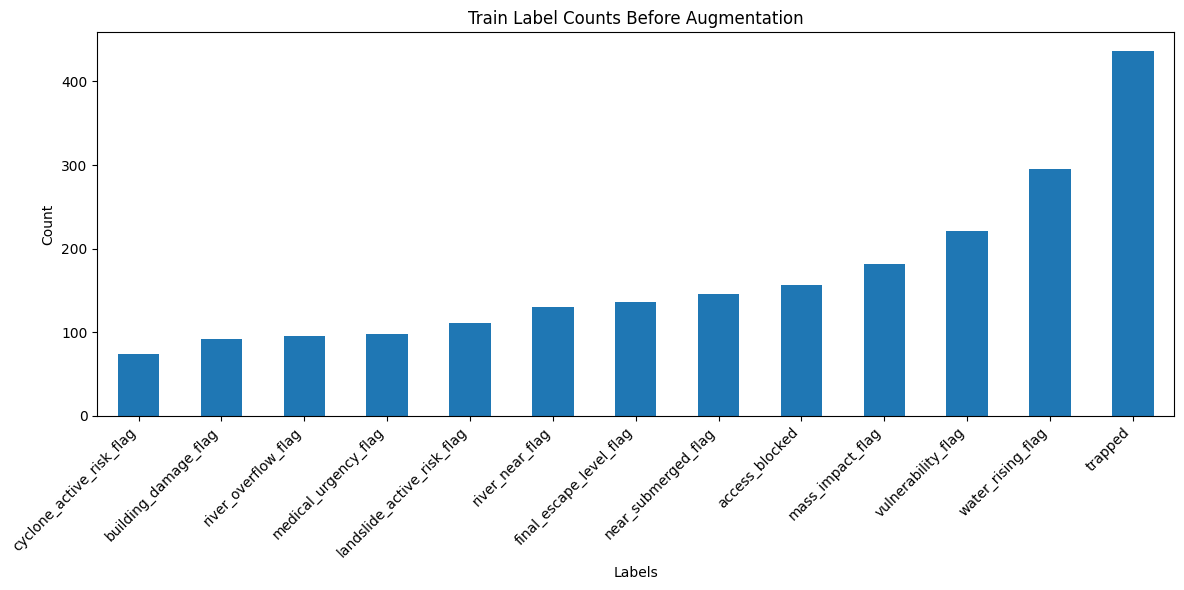

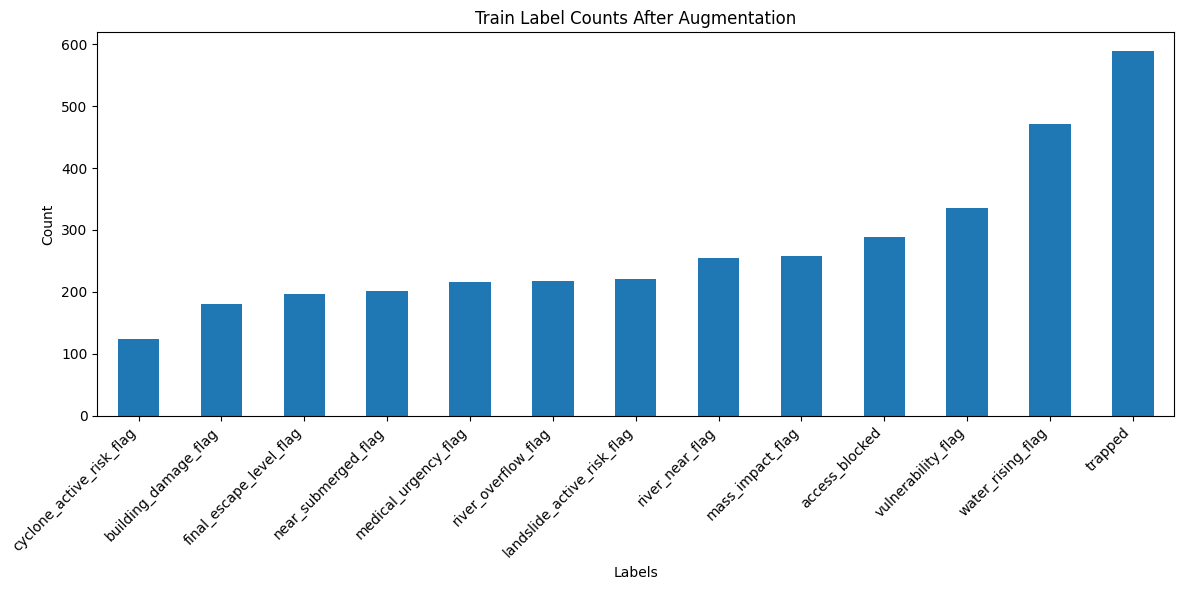

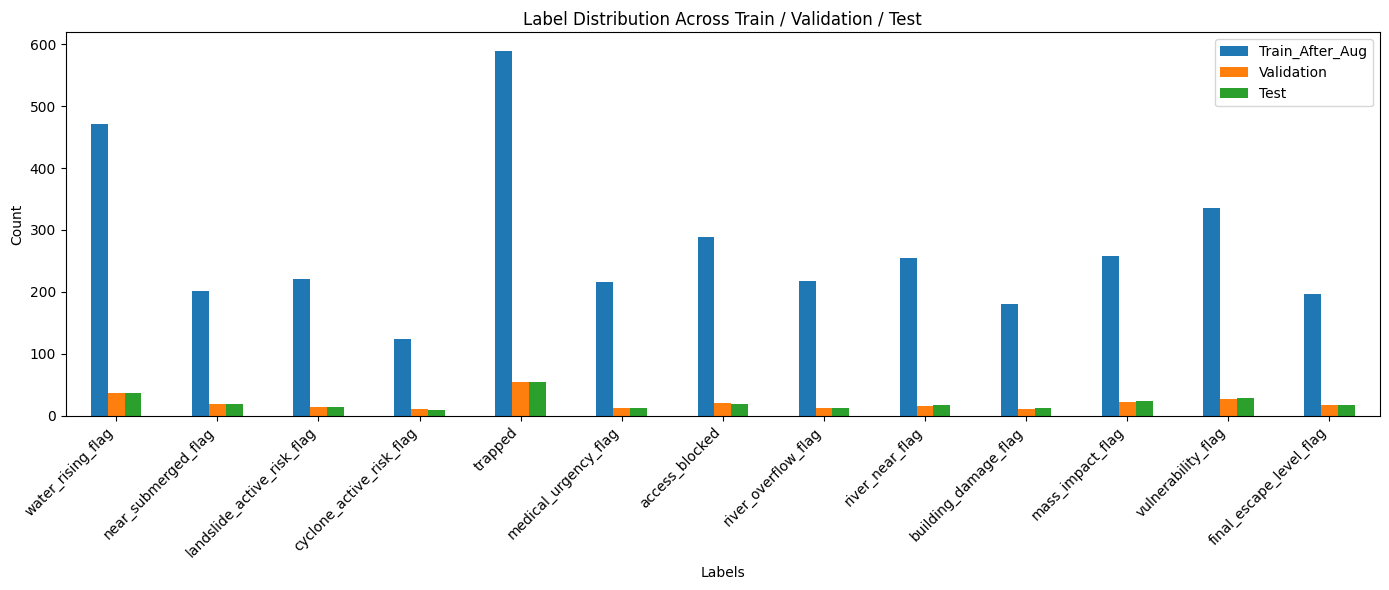

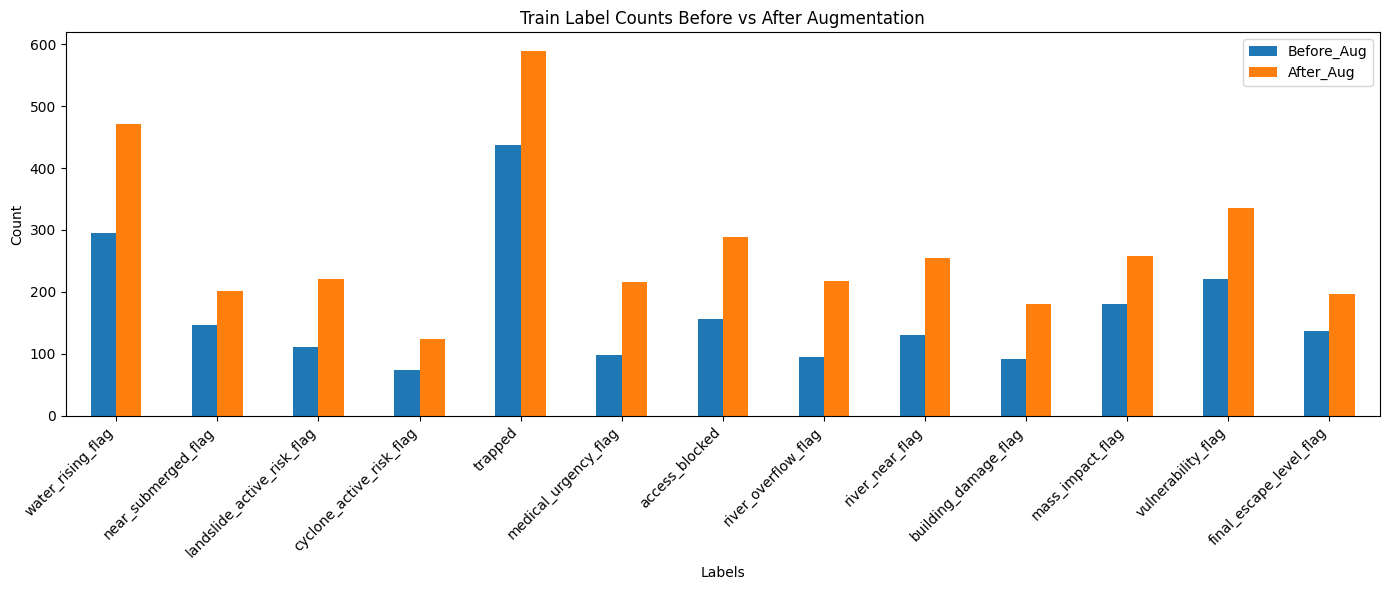

In [9]:

USE_AUGMENTATION = True

SYNONYMS = {
    "trapped": ["stuck", "unable to escape", "blocked inside", "stranded", "unable to get out"],
    "flood": ["flooding", "high water", "overflowing water", "severe flooding"],
    "water": ["water level", "flood water", "rising water"],
    "rising": ["increasing", "going up", "rapidly rising"],
    "blocked": ["closed", "not accessible", "cut off", "obstructed"],
    "road": ["route", "path", "main road", "access road"],
    "people": ["residents", "individuals", "families", "civilians"],
    "house": ["home", "building", "residence"],
    "help": ["assistance", "rescue", "urgent support"],
    "injured": ["hurt", "wounded", "seriously injured"],
    "area": ["region", "location", "zone"],
    "village": ["community", "local area"],
    "near": ["close to", "nearby"],
    "urgent": ["immediate", "critical", "emergency"],
}

def synonym_replace(text, prob=0.35):
    words = text.split()
    new_words = []

    for w in words:
        clean_w = re.sub(r"[^\w]", "", w.lower())
        if clean_w in SYNONYMS and random.random() < prob:
            replacement = random.choice(SYNONYMS[clean_w])
            new_words.append(replacement)
        else:
            new_words.append(w)

    return " ".join(new_words)

def restructure_sentence(text):
    patterns = [
        lambda t: t.replace("people trapped", "people are trapped"),
        lambda t: t.replace("trapped due to", "has been trapped due to"),
        lambda t: t.replace("flood water rising", "water levels are rising due to flooding"),
        lambda t: t.replace("need help", "requires immediate assistance"),
        lambda t: t.replace("road blocked", "road is completely blocked"),
    ]

    if random.random() < 0.5:
        func = random.choice(patterns)
        return func(text)

    return text

def add_context(text):
    prefixes = [
        "urgent situation:",
        "emergency reported:",
        "critical condition:",
        "",
    ]

    suffixes = [
        "please send help",
        "rescue needed immediately",
        "",
    ]

    prefix = random.choice(prefixes)
    suffix = random.choice(suffixes)

    text = f"{prefix} {text}".strip()
    text = f"{text} {suffix}".strip()

    return text

def augment_text(text):
    text = synonym_replace(text, prob=0.35)
    text = restructure_sentence(text)

    if random.random() < 0.3:
        text = add_context(text)

    text = clean_text(text)
    return text

print("\nBefore augmentation:")
print("Train rows:", len(train_df))
print("\nTrain label counts before augmentation:")
print(train_df[LABEL_COLS].sum().sort_values())

train_label_counts_before_aug = train_df[LABEL_COLS].sum().copy()
train_df_original = train_df.copy()

# Automatically select bottom 5 weakest labels from training data
label_counts_for_aug = train_df_original[LABEL_COLS].sum().sort_values()
WEAK_LABELS = label_counts_for_aug.head(5).index.tolist()

print("\nAutomatically selected WEAK_LABELS:")
print(WEAK_LABELS)

print("\nWeak label counts:")
print(label_counts_for_aug.loc[WEAK_LABELS])

augmented_rows = []

if USE_AUGMENTATION:
    print("\nUsing TRAIN augmentation...")

    for _, row in train_df_original.iterrows():
        for label in WEAK_LABELS:
            if row[label] == 1:
                num_aug = random.choice([1, 2])

                for _ in range(num_aug):
                    new_row = row.copy()
                    new_row[TEXT_COL] = augment_text(row[TEXT_COL])

                    if new_row[TEXT_COL] != row[TEXT_COL]:
                        augmented_rows.append(new_row)

                break

    aug_df = pd.DataFrame(augmented_rows)

    if not aug_df.empty:
        aug_df = aug_df.drop_duplicates(subset=[TEXT_COL] + LABEL_COLS).reset_index(drop=True)

    print("\nAugmented samples:", len(aug_df))

    train_df = pd.concat([train_df_original, aug_df], ignore_index=True)
    train_df = train_df.drop_duplicates(subset=[TEXT_COL] + LABEL_COLS).reset_index(drop=True)

else:
    print("\nUsing NO augmentation...")
    aug_df = pd.DataFrame(columns=train_df.columns)
    print("\nAugmented samples:", len(aug_df))
    train_df = train_df_original.copy()

print("New training size:", train_df.shape)

print("\nTrain label counts after augmentation:")
print(train_df[LABEL_COLS].sum().sort_values())

train_label_counts_after_aug = train_df[LABEL_COLS].sum().copy()
val_label_counts = val_df[LABEL_COLS].sum().copy()
test_label_counts = test_df[LABEL_COLS].sum().copy()

print("\nValidation rows:", len(val_df))
print("Test rows:", len(test_df))


plt.figure(figsize=(12, 6))
train_label_counts_before_aug.sort_values().plot(kind="bar")
plt.title("Train Label Counts Before Augmentation")
plt.xlabel("Labels")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
train_label_counts_after_aug.sort_values().plot(kind="bar")
plt.title("Train Label Counts After Augmentation")
plt.xlabel("Labels")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

dist_compare_df = pd.DataFrame({
    "Train_After_Aug": train_label_counts_after_aug,
    "Validation": val_label_counts,
    "Test": test_label_counts,
}).loc[LABEL_COLS]

dist_compare_df.plot(kind="bar", figsize=(14, 6))
plt.title("Label Distribution Across Train / Validation / Test")
plt.xlabel("Labels")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

aug_compare_df = pd.DataFrame({
    "Before_Aug": train_label_counts_before_aug,
    "After_Aug": train_label_counts_after_aug,
}).loc[LABEL_COLS]

aug_compare_df.plot(kind="bar", figsize=(14, 6))
plt.title("Train Label Counts Before vs After Augmentation")
plt.xlabel("Labels")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Computes class weights for each hazard label so rarer positive labels receive higher importance during model training.

In [10]:

train_labels_np = train_df[LABEL_COLS].values.astype(np.float32)
pos_counts = train_labels_np.sum(axis=0)
neg_counts = len(train_df) - pos_counts

pos_weight = np.where(pos_counts > 0, neg_counts / np.maximum(pos_counts, 1), 1.0)
pos_weight = np.clip(pos_weight, 1.0, 5.0)
pos_weight = torch.tensor(pos_weight, dtype=torch.float32)

print("\npos_weight:")
for c, w in zip(LABEL_COLS, pos_weight.tolist()):
    print(f"{c}: {w:.3f}")




pos_weight:
water_rising_flag: 1.472
near_submerged_flag: 4.777
landslide_active_risk_flag: 4.281
cyclone_active_risk_flag: 5.000
trapped: 1.000
medical_urgency_flag: 4.403
access_blocked: 3.038
river_overflow_flag: 4.378
river_near_flag: 3.594
building_damage_flag: 5.000
mass_impact_flag: 3.523
vulnerability_flag: 2.484
final_escape_level_flag: 4.954


Loads the tokenizer, converts the text data into tokenized Hugging Face datasets with label tensors, and prepares them for PyTorch training.

In [11]:

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(batch):
    enc = tokenizer(
        batch[TEXT_COL],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN,
    )
    labels = np.array([batch[col] for col in LABEL_COLS], dtype=np.float32).T
    enc["labels"] = labels.tolist()
    return enc

train_ds = Dataset.from_pandas(train_df, preserve_index=False)
val_ds = Dataset.from_pandas(val_df, preserve_index=False)
test_ds = Dataset.from_pandas(test_df, preserve_index=False)

train_ds = train_ds.map(tokenize_function, batched=True, batch_size=256)
val_ds = val_ds.map(tokenize_function, batched=True, batch_size=256)
test_ds = test_ds.map(tokenize_function, batched=True, batch_size=256)

allowed_cols = ["input_ids", "attention_mask", "token_type_ids", "labels"]

remove_cols_train = [c for c in train_ds.column_names if c not in allowed_cols]
remove_cols_val = [c for c in val_ds.column_names if c not in allowed_cols]
remove_cols_test = [c for c in test_ds.column_names if c not in allowed_cols]

train_ds = train_ds.remove_columns(remove_cols_train)
val_ds = val_ds.remove_columns(remove_cols_val)
test_ds = test_ds.remove_columns(remove_cols_test)

cols_to_keep = ["input_ids", "attention_mask", "labels"]
if "token_type_ids" in train_ds.column_names:
    cols_to_keep.append("token_type_ids")

train_ds.set_format(type="torch", columns=cols_to_keep)
val_ds.set_format(type="torch", columns=cols_to_keep)
test_ds.set_format(type="torch", columns=cols_to_keep)

print("\nSample tokenized row:")
print(train_ds[0])



tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

Map:   0%|          | 0/1167 [00:00<?, ? examples/s]

Map:   0%|          | 0/101 [00:00<?, ? examples/s]

Map:   0%|          | 0/101 [00:00<?, ? examples/s]


Sample tokenized row:
{'input_ids': tensor([    1,   287,   452,  1234,   292,   262,  2734,   265, 32938,  2401,
        36816,   285,   277, 12345, 38030, 56678,  1212,   261,  2905, 48108,
         5370,   261,   312,   410,  1156,   263,   308,   495,   281,  9207,
         1013,   308,   669,   260,   266,   782,   438,   824,   306,   357,
          272,   262,   529,   674,   269,   394,   828,   264,   262,  4454,
          261,   263,   262,   529,  3425,  3951,   497,  5921,   260,   335,
          306,   650,   262,  5069,   895,  3081,   261,   306,   332,   732,
          272,   343,   281,   363,  6831,   499,   260,   306,   286,   637,
         3277,   469,   628,   470,   270,   408,   261,   304,   363,  5432,
          511,   303,  2525,   729,   260,   811,   408,   349,   283,   950,
          283,   628,   337,  1012,   295,  2263,   260,  1045,   294,   355,
          294,   578,  7374,  5061,   294,   574,   260,  4425, 61937,  1984,
          261,  9391,   260

Loads the pretrained DeBERTa model for multilabel text classification with the required number of hazard labels.

In [12]:

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABEL_COLS),
    problem_type="multi_label_classification",
    use_safetensors=False
)



pytorch_model.bin:   0%|          | 0.00/286M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-small and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Defines a custom Trainer that uses weighted binary cross-entropy loss for stable multilabel model training.

In [13]:

class MultiLabelTrainer(Trainer):
    def __init__(self, *args, pos_weight=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.pos_weight = pos_weight

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels").float()
        outputs = model(**inputs)
        logits = outputs.logits

        if torch.isnan(logits).any() or torch.isinf(logits).any():
            raise ValueError("Logits contain NaN or Inf")

        if self.pos_weight is not None:
            loss_fct = nn.BCEWithLogitsLoss(
                pos_weight=self.pos_weight.to(logits.device)
            )
        else:
            loss_fct = nn.BCEWithLogitsLoss()

        loss = loss_fct(logits, labels)

        if torch.isnan(loss) or torch.isinf(loss):
            raise ValueError("Loss became NaN or Inf")

        return (loss, outputs) if return_outputs else loss


Defines stable sigmoid conversion and evaluation metrics for multilabel prediction performance.

In [14]:

def sigmoid_stable(x):
    x = np.clip(x, -50, 50)
    return 1.0 / (1.0 + np.exp(-x))

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = sigmoid_stable(logits)
    preds = (probs >= BASE_THRESHOLD).astype(int)

    return {
        "micro_f1": f1_score(labels, preds, average="micro", zero_division=0),
        "macro_f1": f1_score(labels, preds, average="macro", zero_division=0),
        "samples_f1": f1_score(labels, preds, average="samples", zero_division=0),
        "subset_accuracy": accuracy_score(labels, preds),
    }



Sets the training configuration for the DeBERTa multilabel model, including evaluation, optimization, batching, and checkpoint settings.

In [15]:

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=20,
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=0.1,
    max_grad_norm=1.0,
    lr_scheduler_type="linear",
    load_best_model_at_end=True,
    metric_for_best_model="micro_f1",
    greater_is_better=True,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    bf16=False,
    report_to="none",
    seed=SEED,
    dataloader_num_workers=2,
    remove_unused_columns=False,
)



model.safetensors:   0%|          | 0.00/286M [00:00<?, ?B/s]

Configures whether class-weighted loss will be used during multilabel model training to address label imbalance.

In [16]:

USE_POS_WEIGHT = True

if USE_POS_WEIGHT:
    trainer_pos_weight = pos_weight
    print("\nUsing pos_weight in BCEWithLogitsLoss")
else:
    trainer_pos_weight = None
    print("\nUsing NO pos_weight in BCEWithLogitsLoss")


Using pos_weight in BCEWithLogitsLoss


Initializes the custom Hugging Face trainer with the model, datasets, tokenizer, metrics, weighted loss, and early stopping.

In [17]:

trainer = MultiLabelTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    pos_weight=trainer_pos_weight,
    callbacks=[EarlyStoppingCallback(
    early_stopping_patience=2,
    early_stopping_threshold=0.001
)]
)

Trains the DeBERTa multilabel model and outputs the training result summary.

In [18]:

train_result = trainer.train()
print("\nTraining complete.")
print(train_result)



Epoch,Training Loss,Validation Loss,Micro F1,Macro F1,Samples F1,Subset Accuracy
1,1.058700,0.979009,0.328147,0.147271,0.318927,0.000000
2,0.900400,0.777205,0.547397,0.516862,0.484180,0.019802
3,0.632800,0.565004,0.675516,0.683042,0.632284,0.128713
4,0.541600,0.479797,0.728376,0.733378,0.679623,0.198020
5,0.431500,0.437121,0.739645,0.736035,0.700795,0.217822
6,0.406700,0.387357,0.787402,0.781733,0.747992,0.297030
7,0.354600,0.372090,0.808989,0.802087,0.749556,0.346535
8,0.294100,0.349774,0.811784,0.808774,0.758476,0.366337
9,0.266500,0.330942,0.814570,0.808308,0.768200,0.415842
10,0.242200,0.313429,0.852234,0.849017,0.798188,0.485149



Training complete.
TrainOutput(global_step=2920, training_loss=0.3634860542539048, metrics={'train_runtime': 1494.4105, 'train_samples_per_second': 15.618, 'train_steps_per_second': 1.954, 'total_flos': 966408040915200.0, 'train_loss': 0.3634860542539048, 'epoch': 20.0})


Uses validation predictions to tune both a global threshold and label-specific thresholds, then visualizes the best threshold for each hazard label.


Best threshold from validation: 0.60
Best validation micro-F1: 0.8924

Best per-label thresholds:
water_rising_flag: 0.75
near_submerged_flag: 0.70
landslide_active_risk_flag: 0.20
cyclone_active_risk_flag: 0.20
trapped: 0.60
medical_urgency_flag: 0.75
access_blocked: 0.60
river_overflow_flag: 0.70
river_near_flag: 0.60
building_damage_flag: 0.80
mass_impact_flag: 0.65
vulnerability_flag: 0.55
final_escape_level_flag: 0.80


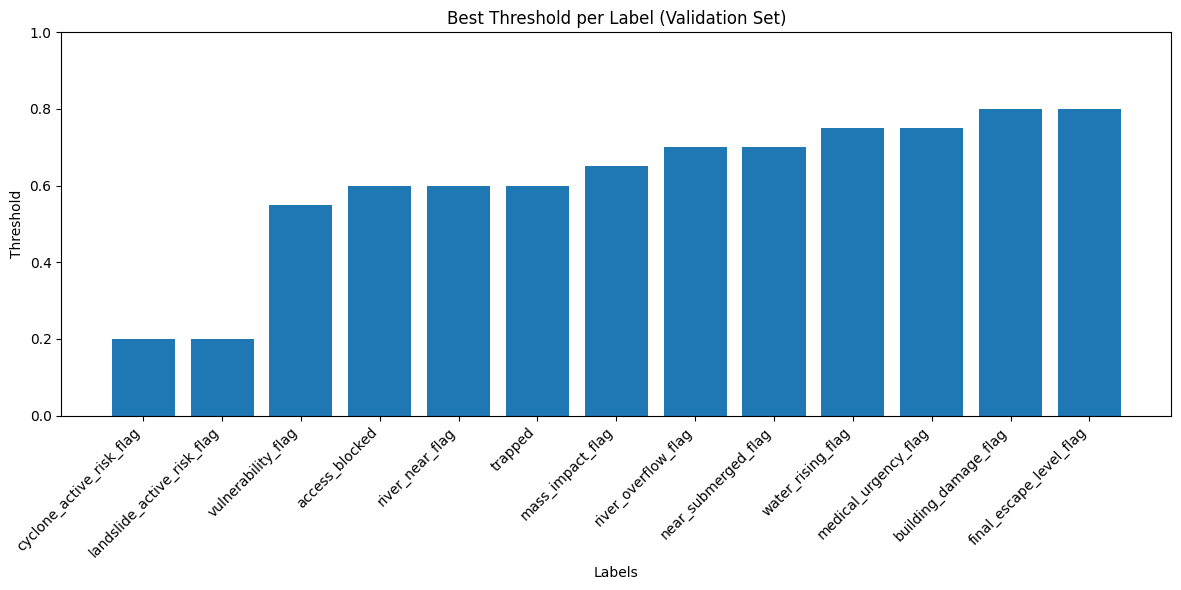

In [19]:

val_preds = trainer.predict(val_ds)
val_logits = val_preds.predictions
val_labels = val_preds.label_ids

if np.isnan(val_logits).any() or np.isinf(val_logits).any():
    raise ValueError("Validation logits contain NaN or Inf")

val_probs = sigmoid_stable(val_logits)

best_threshold = 0.5
best_f1 = -1.0

for t in np.arange(0.20, 0.81, 0.05):
    pred_bin = (val_probs >= t).astype(int)
    f1 = f1_score(val_labels, pred_bin, average="micro", zero_division=0)
    if f1 > best_f1:
        best_f1 = float(f1)
        best_threshold = float(t)

print(f"\nBest threshold from validation: {best_threshold:.2f}")
print(f"Best validation micro-F1: {best_f1:.4f}")

best_thresholds_per_label = []
for i in range(len(LABEL_COLS)):
    best_t = 0.5
    best_label_f1 = -1.0
    y_true = val_labels[:, i]
    y_prob = val_probs[:, i]

    for t in np.arange(0.20, 0.81, 0.05):
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_label_f1:
            best_label_f1 = float(f1)
            best_t = float(t)

    best_thresholds_per_label.append(best_t)

best_thresholds_per_label = np.array(best_thresholds_per_label, dtype=np.float32)

print("\nBest per-label thresholds:")
for label, thr in zip(LABEL_COLS, best_thresholds_per_label):
    print(f"{label}: {thr:.2f}")


threshold_plot_df = pd.DataFrame({
    "label": LABEL_COLS,
    "best_threshold": best_thresholds_per_label
}).sort_values("best_threshold")

plt.figure(figsize=(12, 6))
plt.bar(threshold_plot_df["label"], threshold_plot_df["best_threshold"])
plt.title("Best Threshold per Label (Validation Set)")
plt.xlabel("Labels")
plt.ylabel("Threshold")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()




Evaluates the final DeBERTa model on the test set using global and per-label thresholds, generates detailed per-label metrics and visualizations, and compares performance against the baseline model


TEST RESULTS (GLOBAL THRESHOLD)
Micro F1: 0.831858407079646
Macro F1: 0.833738883176979
Samples F1: 0.7286280276379286
Subset accuracy: 0.48514851485148514

TEST RESULTS (PER-LABEL THRESHOLDS)
Micro F1: 0.8419117647058824
Macro F1: 0.8390563764282611
Samples F1: 0.7363910566880864
Subset accuracy: 0.5346534653465347

Per-label metrics summary:
                         label  precision    recall        f1  support
3     cyclone_active_risk_flag   1.000000  1.000000  1.000000        9
9         building_damage_flag   1.000000  0.916667  0.956522       12
11          vulnerability_flag   0.896552  0.928571  0.912281       28
4                      trapped   0.909091  0.909091  0.909091       55
2   landslide_active_risk_flag   0.823529  1.000000  0.903226       14
6               access_blocked   0.850000  0.894737  0.871795       19
0            water_rising_flag   0.931034  0.729730  0.818182       37
7          river_overflow_flag   0.769231  0.833333  0.800000       12
5         medi

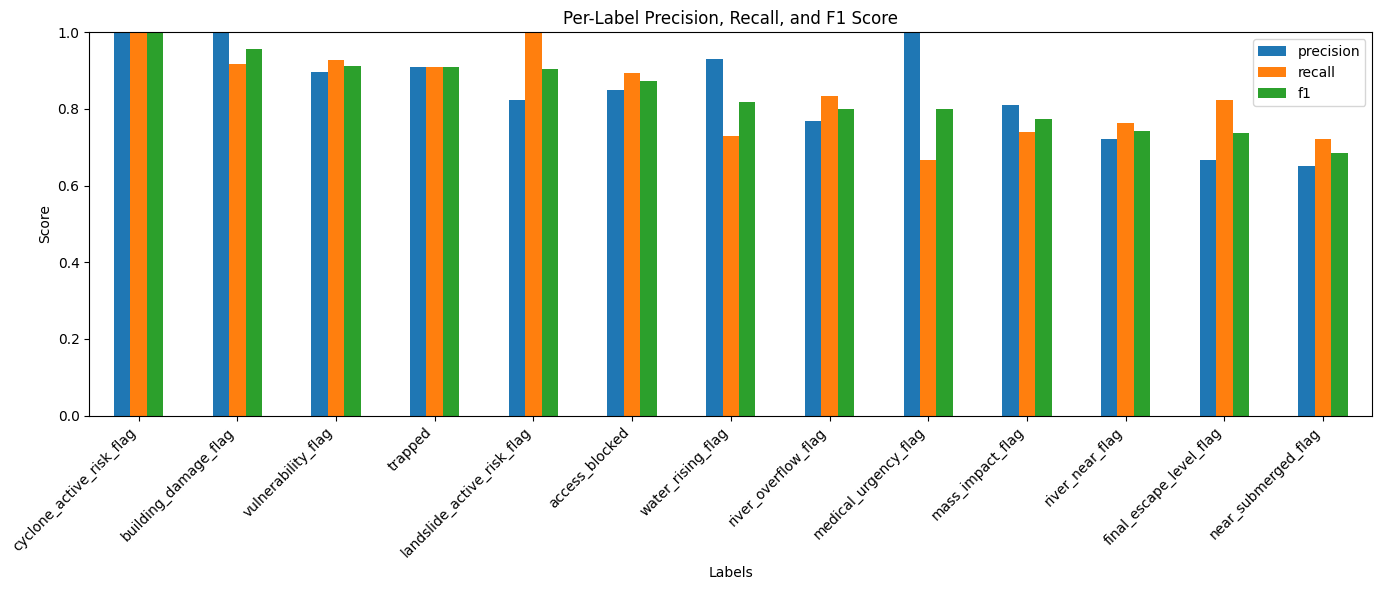

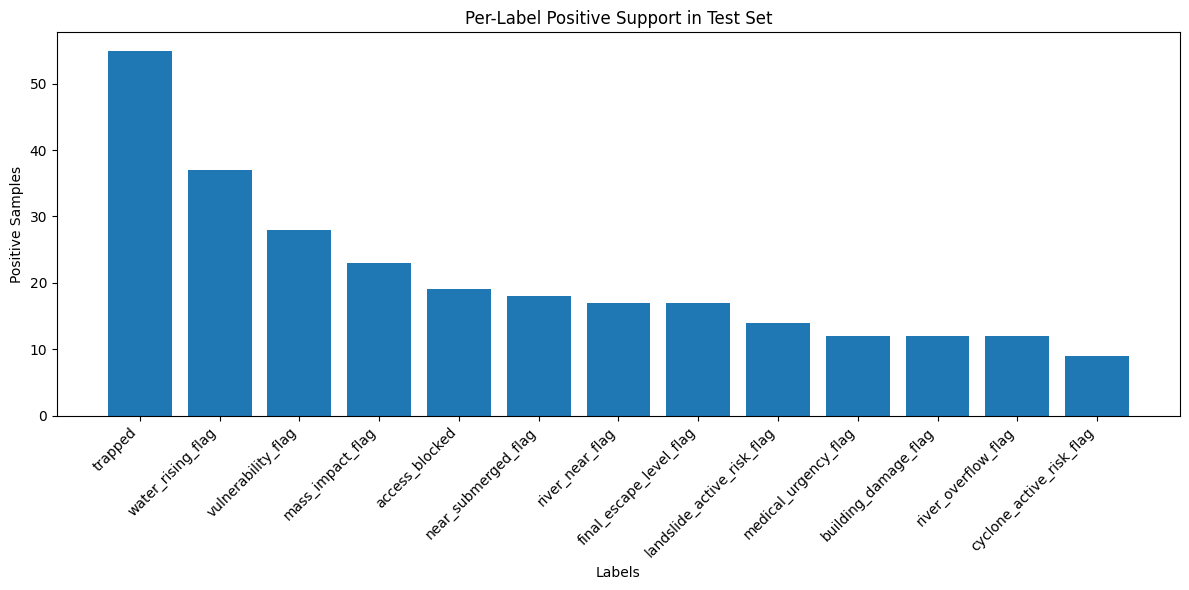

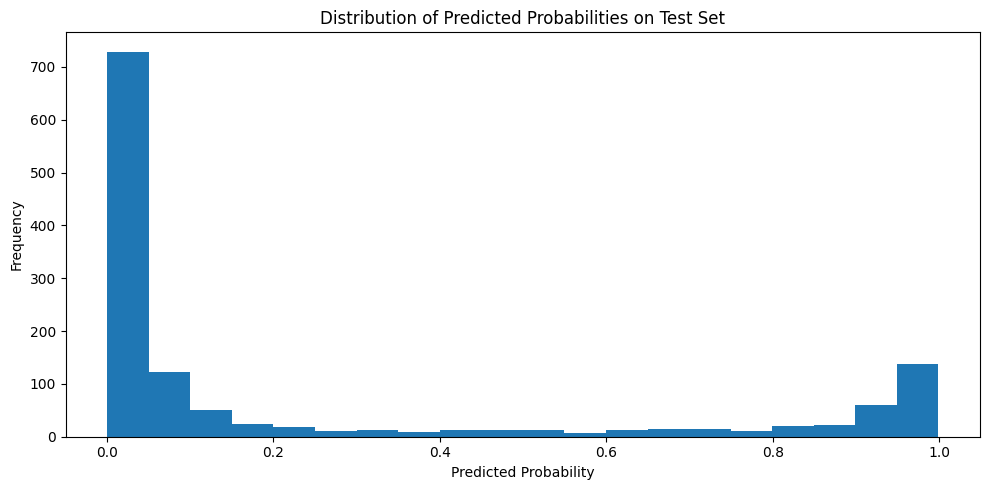


Per-label report (per-label thresholds):

===== water_rising_flag =====
              precision    recall  f1-score   support

         0.0       0.86      0.97      0.91        64
         1.0       0.93      0.73      0.82        37

    accuracy                           0.88       101
   macro avg       0.90      0.85      0.86       101
weighted avg       0.89      0.88      0.88       101


===== near_submerged_flag =====
              precision    recall  f1-score   support

         0.0       0.94      0.92      0.93        83
         1.0       0.65      0.72      0.68        18

    accuracy                           0.88       101
   macro avg       0.79      0.82      0.81       101
weighted avg       0.89      0.88      0.88       101


===== landslide_active_risk_flag =====
              precision    recall  f1-score   support

         0.0       1.00      0.97      0.98        87
         1.0       0.82      1.00      0.90        14

    accuracy                        

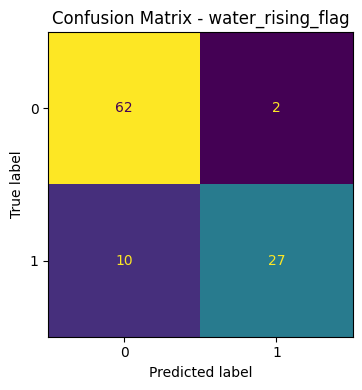

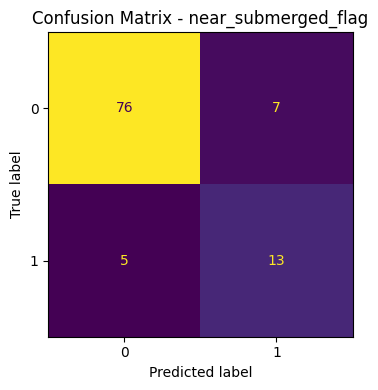

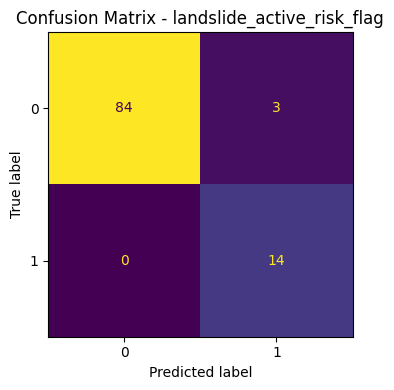

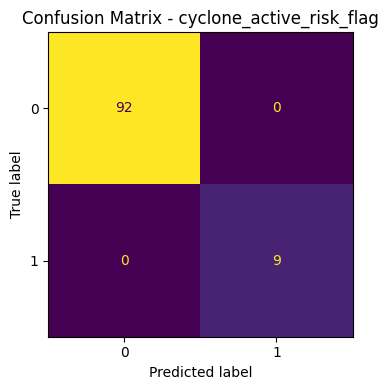

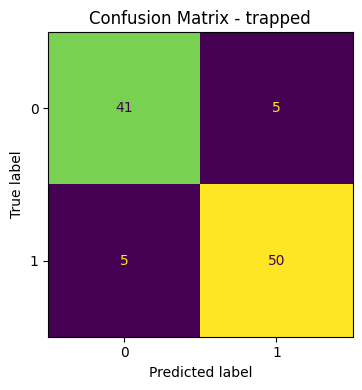

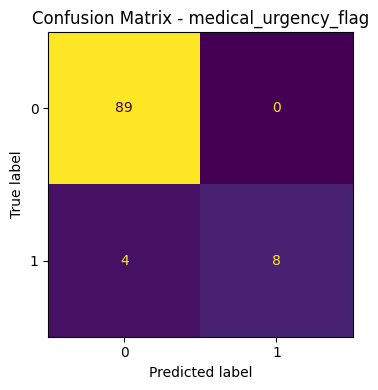

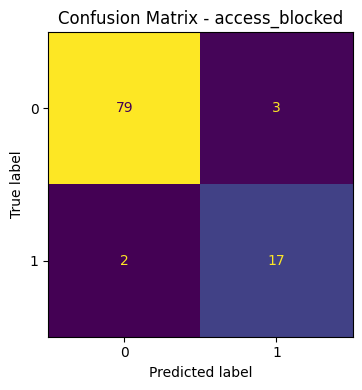

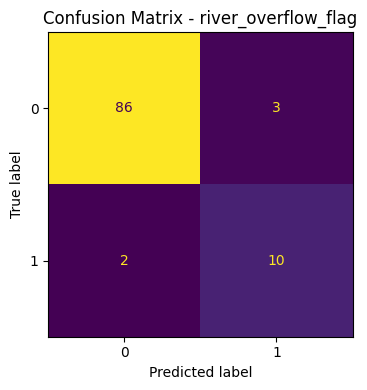

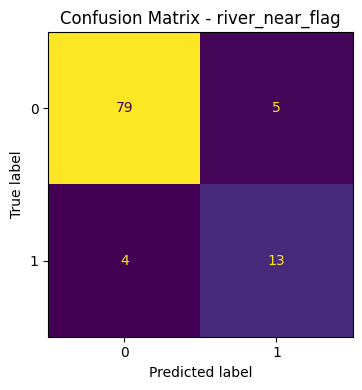

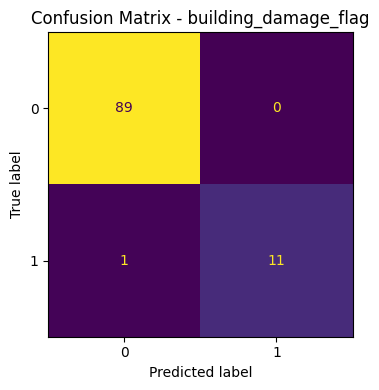

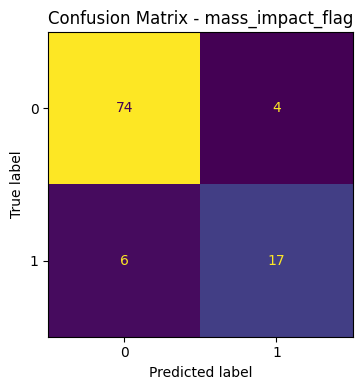

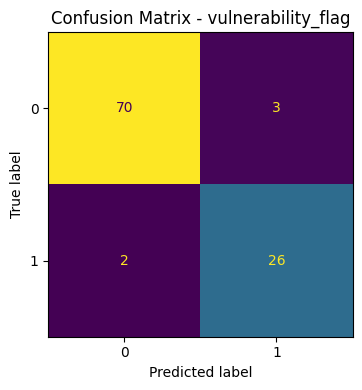

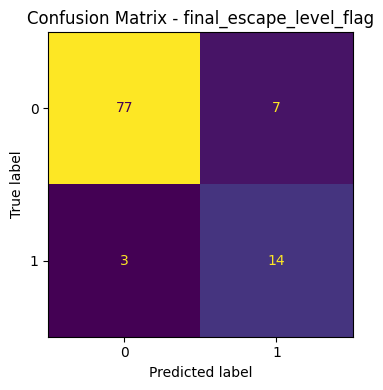


Baseline vs Final Model Comparison:
                                     model  micro_f1  macro_f1  samples_f1  \
0         TF-IDF + OVR Logistic Regression  0.805100  0.793776    0.698960   
1  DeBERTa-v3-small (Per-label Thresholds)  0.841912  0.839056    0.736391   

   subset_accuracy  
0         0.445545  
1         0.534653  

Saved comparison file to: final_deberta_multilabel_model_aug/baseline_vs_deberta_comparison.csv


In [20]:

FINAL_SAVE_DIR = "final_deberta_multilabel_model_aug"
os.makedirs(FINAL_SAVE_DIR, exist_ok=True)


test_preds = trainer.predict(test_ds)
test_logits = test_preds.predictions
test_labels = test_preds.label_ids

if np.isnan(test_logits).any() or np.isinf(test_logits).any():
    raise ValueError("Test logits contain NaN or Inf")

test_probs = sigmoid_stable(test_logits)


# Global threshold evaluation

test_bin_global = (test_probs >= best_threshold).astype(int)

print("\nTEST RESULTS (GLOBAL THRESHOLD)")
print("Micro F1:", f1_score(test_labels, test_bin_global, average="micro", zero_division=0))
print("Macro F1:", f1_score(test_labels, test_bin_global, average="macro", zero_division=0))
print("Samples F1:", f1_score(test_labels, test_bin_global, average="samples", zero_division=0))
print("Subset accuracy:", accuracy_score(test_labels, test_bin_global))


# Per-label threshold evaluation

test_bin_labelwise = (test_probs >= best_thresholds_per_label.reshape(1, -1)).astype(int)

print("\nTEST RESULTS (PER-LABEL THRESHOLDS)")
print("Micro F1:", f1_score(test_labels, test_bin_labelwise, average="micro", zero_division=0))
print("Macro F1:", f1_score(test_labels, test_bin_labelwise, average="macro", zero_division=0))
print("Samples F1:", f1_score(test_labels, test_bin_labelwise, average="samples", zero_division=0))
print("Subset accuracy:", accuracy_score(test_labels, test_bin_labelwise))



#  PER-LABEL METRICS TABLE

per_label_results = []

for i, col in enumerate(LABEL_COLS):
    y_true = test_labels[:, i]
    y_pred = test_bin_labelwise[:, i]

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    support = int(y_true.sum())

    per_label_results.append({
        "label": col,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support
    })

per_label_df = pd.DataFrame(per_label_results).sort_values("f1", ascending=False)

print("\nPer-label metrics summary:")
print(per_label_df)

per_label_df.to_csv(os.path.join(FINAL_SAVE_DIR, "per_label_metrics.csv"), index=False)


# 18.2 PER-LABEL PRECISION / RECALL / F1 CHART

metrics_plot_df = per_label_df.set_index("label")[["precision", "recall", "f1"]]

metrics_plot_df.plot(kind="bar", figsize=(14, 6))
plt.title("Per-Label Precision, Recall, and F1 Score")
plt.xlabel("Labels")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


# PER-LABEL SUPPORT CHART

support_plot_df = per_label_df.sort_values("support", ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(support_plot_df["label"], support_plot_df["support"])
plt.title("Per-Label Positive Support in Test Set")
plt.xlabel("Labels")
plt.ylabel("Positive Samples")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# PROBABILITY DISTRIBUTION CHART
all_probs_flat = test_probs.flatten()

plt.figure(figsize=(10, 5))
plt.hist(all_probs_flat, bins=20)
plt.title("Distribution of Predicted Probabilities on Test Set")
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("\nPer-label report (per-label thresholds):")
for i, col in enumerate(LABEL_COLS):
    print(f"\n===== {col} =====")
    print(classification_report(test_labels[:, i], test_bin_labelwise[:, i], zero_division=0))


#  CONFUSION MATRIX PER LABEL

for i, col in enumerate(LABEL_COLS):
    cm = confusion_matrix(test_labels[:, i], test_bin_labelwise[:, i])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

    fig, ax = plt.subplots(figsize=(4, 4))
    disp.plot(ax=ax, colorbar=False)
    plt.title(f"Confusion Matrix - {col}")
    plt.tight_layout()
    plt.show()


#  BASELINE VS DEBERTA COMPARISON

# Rebuild baseline results only if not already available
if "baseline_results" not in globals():
    baseline_results = {
        "model": "TF-IDF + OVR Logistic Regression",
        "micro_f1": f1_score(test_df[LABEL_COLS], test_pred_baseline, average="micro", zero_division=0),
        "macro_f1": f1_score(test_df[LABEL_COLS], test_pred_baseline, average="macro", zero_division=0),
        "samples_f1": f1_score(test_df[LABEL_COLS], test_pred_baseline, average="samples", zero_division=0),
        "subset_accuracy": accuracy_score(test_df[LABEL_COLS], test_pred_baseline),
    }

deberta_results = {
    "model": "DeBERTa-v3-small (Per-label Thresholds)",
    "micro_f1": f1_score(test_labels, test_bin_labelwise, average="micro", zero_division=0),
    "macro_f1": f1_score(test_labels, test_bin_labelwise, average="macro", zero_division=0),
    "samples_f1": f1_score(test_labels, test_bin_labelwise, average="samples", zero_division=0),
    "subset_accuracy": accuracy_score(test_labels, test_bin_labelwise),
}

comparison_df = pd.DataFrame([baseline_results, deberta_results])

print("\nBaseline vs Final Model Comparison:")
print(comparison_df)

comparison_path = os.path.join(FINAL_SAVE_DIR, "baseline_vs_deberta_comparison.csv")
comparison_df.to_csv(comparison_path, index=False)

print(f"\nSaved comparison file to: {comparison_path}")



Saves the final DeBERTa model, tokenizer, threshold settings, comparison results, and per-label test metrics for deployment and future use.

In [21]:

os.makedirs(FINAL_SAVE_DIR, exist_ok=True)
comparison_df.to_csv(os.path.join(FINAL_SAVE_DIR, "baseline_vs_deberta_comparison.csv"), index=False)
trainer.save_model(FINAL_SAVE_DIR)
tokenizer.save_pretrained(FINAL_SAVE_DIR)

threshold_df = pd.DataFrame({
    "label": LABEL_COLS,
    "best_threshold": best_thresholds_per_label
})
threshold_df.to_csv(os.path.join(FINAL_SAVE_DIR, "label_thresholds.csv"), index=False)

per_label_df.to_csv(os.path.join(FINAL_SAVE_DIR, "per_label_test_metrics.csv"), index=False)

print(f"\nModel saved to: {FINAL_SAVE_DIR}")




Model saved to: final_deberta_multilabel_model_aug


Defines an inference function that cleans new text, predicts label probabilities, applies global or per-label thresholds, and returns the final hazard prediction results.

In [22]:

def predict_text(
    text,
    model,
    tokenizer,
    label_cols,
    threshold_mode="per_label",
    global_threshold=0.5,
    label_thresholds=None,
    max_len=160,
):
    model.eval()
    cleaned = clean_text(text)

    enc = tokenizer(
        cleaned,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=max_len,
    )
    enc = {k: v.to(model.device) for k, v in enc.items()}

    with torch.no_grad():
        outputs = model(**enc)
        logits = outputs.logits
        if torch.isnan(logits).any() or torch.isinf(logits).any():
            raise ValueError("Prediction logits contain NaN or Inf")
        probs = torch.sigmoid(logits).cpu().numpy()[0]

    probs = np.clip(probs, 0.0, 1.0)

    if threshold_mode == "per_label":
        if label_thresholds is None:
            raise ValueError("label_thresholds must be provided when threshold_mode='per_label'")
        preds = (probs >= np.array(label_thresholds)).astype(int)
        used_thresholds = np.array(label_thresholds)
    else:
        preds = (probs >= global_threshold).astype(int)
        used_thresholds = np.full(len(label_cols), global_threshold)

    result = pd.DataFrame({
        "label": label_cols,
        "probability": probs,
        "threshold": used_thresholds,
        "predicted": preds
    }).sort_values("probability", ascending=False).reset_index(drop=True)

    return result



In [23]:

# EXAMPLE

sample_text = "flood water rising. 5 people trapped need help"

result = predict_text(
    text=sample_text,
    model=trainer.model,
    tokenizer=tokenizer,
    label_cols=LABEL_COLS,
    threshold_mode="per_label",
    label_thresholds=best_thresholds_per_label,
    max_len=MAX_LEN,
)

print("\nPrediction for sample text:")
print(result)

print("\nPredicted positive labels:")
print(result[result["predicted"] == 1][["label", "probability", "threshold"]])


Prediction for sample text:
                         label  probability  threshold  predicted
0                      trapped     0.794385       0.60          1
1            water_rising_flag     0.679179       0.75          0
2             mass_impact_flag     0.356447       0.65          0
3          near_submerged_flag     0.055311       0.70          0
4              river_near_flag     0.040693       0.60          0
5           vulnerability_flag     0.018582       0.55          0
6         medical_urgency_flag     0.015785       0.75          0
7      final_escape_level_flag     0.011115       0.80          0
8     cyclone_active_risk_flag     0.005448       0.20          0
9          river_overflow_flag     0.004849       0.70          0
10              access_blocked     0.004755       0.60          0
11        building_damage_flag     0.002551       0.80          0
12  landslide_active_risk_flag     0.001472       0.20          0

Predicted positive labels:
     label  probabi

In [24]:

# DOWNLOAD SAVED MODEL FOLDER

import shutil
from google.colab import files

zip_name = FINAL_SAVE_DIR + ".zip"


shutil.make_archive(FINAL_SAVE_DIR, "zip", FINAL_SAVE_DIR)


files.download(zip_name)

KeyboardInterrupt: 